### Reloading data

In [2]:
%%time
import os
import json
import numpy as np

SAVE_DIR = "/mnt/scratch/fast0/amaustin/datasets/fife/"
targets = np.load(os.path.join(SAVE_DIR, "targets_and_masks.npz"))

# for key in targets.files:
#     np.save(os.path.join(SAVE_DIR, f"{key}.npy"), targets[key])

Xmatch = np.load(os.path.join(SAVE_DIR, "Xmatch.npy"), mmap_mode="r")
Xsub = np.load(os.path.join(SAVE_DIR, "Xsub.npy"), mmap_mode="r")

failed = np.load(os.path.join(SAVE_DIR, "failed.npy"), mmap_mode="r")
hw = np.load(os.path.join(SAVE_DIR, "hw.npy"), mmap_mode="r")
wait_sv = np.load(os.path.join(SAVE_DIR, "wait_sv.npy"), mmap_mode="r")
tr_mask = np.load(os.path.join(SAVE_DIR, "tr_mask.npy"), mmap_mode="r")
te_mask = np.load(os.path.join(SAVE_DIR, "te_mask.npy"), mmap_mode="r")

with open(os.path.join(SAVE_DIR, "schema_meta.json"), "r") as f:
    meta = json.load(f)

XMATCH_COLS = meta["XMATCH_COLS"]
XSUB_COLS = meta["XSUB_COLS"]
cards = meta["cards"]
NCAT_MATCH = meta["NCAT_MATCH"]
NCAT_SUB = meta["NCAT_SUB"]
n_base = meta["n_base"]

X = Xmatch[:, :n_base]

print(f"Loaded Xmatch {Xmatch.shape} and Xsub {Xsub.shape}")
print(f"Train split: {tr_mask.sum():,} rows | Test split: {te_mask.sum():,} rows")

Loaded Xmatch (64025075, 46) and Xsub (64025075, 27)
Train split: 48,546,633 rows | Test split: 15,478,442 rows
CPU times: user 81.2 ms, sys: 11 ms, total: 92.1 ms
Wall time: 91.7 ms


In [4]:
import glob 
import os

MODEL_DIRS = [
    "/mnt/scratch/fast0/amaustin/dl-tabular-models/",
    "/mnt/scratch/fast0/amaustin/models/",
    "/mnt/scratch/fast0/amaustin/tree-models/",
]

model_paths = []
for d in MODEL_DIRS:
    if os.path.exists(d):
        for ext in ["*.pt", "*.zip", "*.joblib", "*.pkl", "*.model", "*.bin", "*.txt", "*.json"]:
            for path in glob.glob(os.path.join(d, ext)):
                if ("reg_e2_temporal" in os.path.basename(path)):
                    print("appending model path:", path)
                    model_paths.append(path)

print(f"Found {len(model_paths)} candidate model file(s).")

appending model path: /mnt/scratch/fast0/amaustin/dl-tabular-models/saint_reg_e2_temporal.pt
appending model path: /mnt/scratch/fast0/amaustin/dl-tabular-models/ft_reg_e2_temporal.pt
appending model path: /mnt/scratch/fast0/amaustin/dl-tabular-models/mlp_reg_e2_temporal.pt
appending model path: /mnt/scratch/fast0/amaustin/dl-tabular-models/tabnet_reg_e2_temporal.zip
appending model path: /mnt/scratch/fast0/amaustin/dl-tabular-models/hierarchical_reg_e2_temporal.joblib
appending model path: /mnt/scratch/fast0/amaustin/models/lightgbm_reg_e2_temporal.txt
appending model path: /mnt/scratch/fast0/amaustin/models/catboost_reg_e2_temporal.txt
appending model path: /mnt/scratch/fast0/amaustin/tree-models/xgboost_reg_e2_temporal.json
Found 8 candidate model file(s).


### Re-evaluating models (skip if needed)

In [ ]:
%%time
import os
import json
import warnings
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import evaluate_wait_models

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

X_test = Xsub[te_mask]
y_test_raw = wait_sv[te_mask]
campaign_ids_test = X_test[:, XSUB_COLS.index("CampaignId")]
campaign_group_cols_test = {"Group": X_test[:, XSUB_COLS.index("Group")]}

df_results, results_by_model, campaign_by_model = evaluate_wait_models(
    model_paths=model_paths,
    X_test=X_test,
    y_test_raw=y_test_raw,
    is_log_pred=True,
    campaign_ids=campaign_ids_test,
    campaign_group_cols=campaign_group_cols_test,
)

wait_json_path = "output/wait_time_results.json"
data = {}
if os.path.exists(wait_json_path) and os.path.getsize(wait_json_path) > 0:
    with open(wait_json_path) as f:
        data = json.load(f)
for raw_key, mm in results_by_model.items():
    data.setdefault(raw_key, {})["temporal"] = mm
with open(wait_json_path, "w") as f:
    json.dump(data, f, indent=2)

campaign_json_path = "output/wait_time_campaign_results.json"
with open(campaign_json_path, "w") as f:
    json.dump(campaign_by_model, f, indent=2)

print(
    f"Appended {wait_json_path}; saved per-campaign breakdown for "
    f"{len(campaign_by_model)} models to {campaign_json_path}. "
    f"Figures below read df_results/results_by_model/campaign_by_model "
    f"directly from this cell, not from disk."
)

### Performance by model and wait-time bin

Reads the completed runs from `results/wait_time_results.json` rather than the
in-memory `df_results` above, so the figure renders without re-running inference.

In [4]:
import json
import numpy as np
import pandas as pd
import importlib
import eval.helper 
importlib.reload(eval.helper)
from eval.helper import MODEL_DISPLAY_NAMES

RESULTS_PATH = "results/wait_time_results.json"
SPLIT = "temporal"
# A model with r2_log < 0 does worse than predicting the mean wait for every
# job, so its per-bin errors describe a model no one would deploy. Flip to
# False to keep them in the figures for diagnostic purposes.
DROP_NEGATIVE_R2 = True

with open(RESULTS_PATH) as f:
    _raw = json.load(f)

df_wait = pd.DataFrame([
    {"model": MODEL_DISPLAY_NAMES.get(key, key), **splits[SPLIT]}
    for key, splits in _raw.items()
    if SPLIT in splits
])

_dropped = df_wait.loc[df_wait["r2_log"] < 0, "model"].tolist()
if DROP_NEGATIVE_R2 and _dropped:
    df_wait = df_wait[df_wait["r2_log"] >= 0]

# Ranked by overall median AE, which is the headline number the figures below
# order their rows by.
df_wait = df_wait.sort_values("median_ae_s").set_index("model")

print(f"{RESULTS_PATH} :: {SPLIT} split :: {len(df_wait)} model(s)")
if _dropped:
    kept = "excluded" if DROP_NEGATIVE_R2 else "kept"
    print(f"  r2_log < 0 ({kept}): {', '.join(_dropped)}")
display(df_wait[["r2_log", "median_ae_s", "mae_raw_s", "within2x"]].round(3))

results/wait_time_results.json :: temporal split :: 8 model(s)
  r2_log < 0 (excluded): MLP


,r2_log,median_ae_s,mae_raw_s,within2x
model,,,,
CatBoost,0.267,1851.271,10367.119,0.285
TabNet,0.198,1901.006,11295.077,0.285
Hierarchical,0.256,1950.087,10283.316,0.285
LightGBM,0.212,1972.129,10824.228,0.277
XGBoost,0.228,1973.456,10622.584,0.282
SAINT,0.208,2077.499,12127.009,0.297
FT-Transformer,0.173,2101.068,11535.564,0.285
TSMixer,0.110,2454.067,10544.028,0.275


Test samples: 13,532,387
Wait range: 1.0s to 1245639.0s | Global Median: 2082.0s (34.7m)


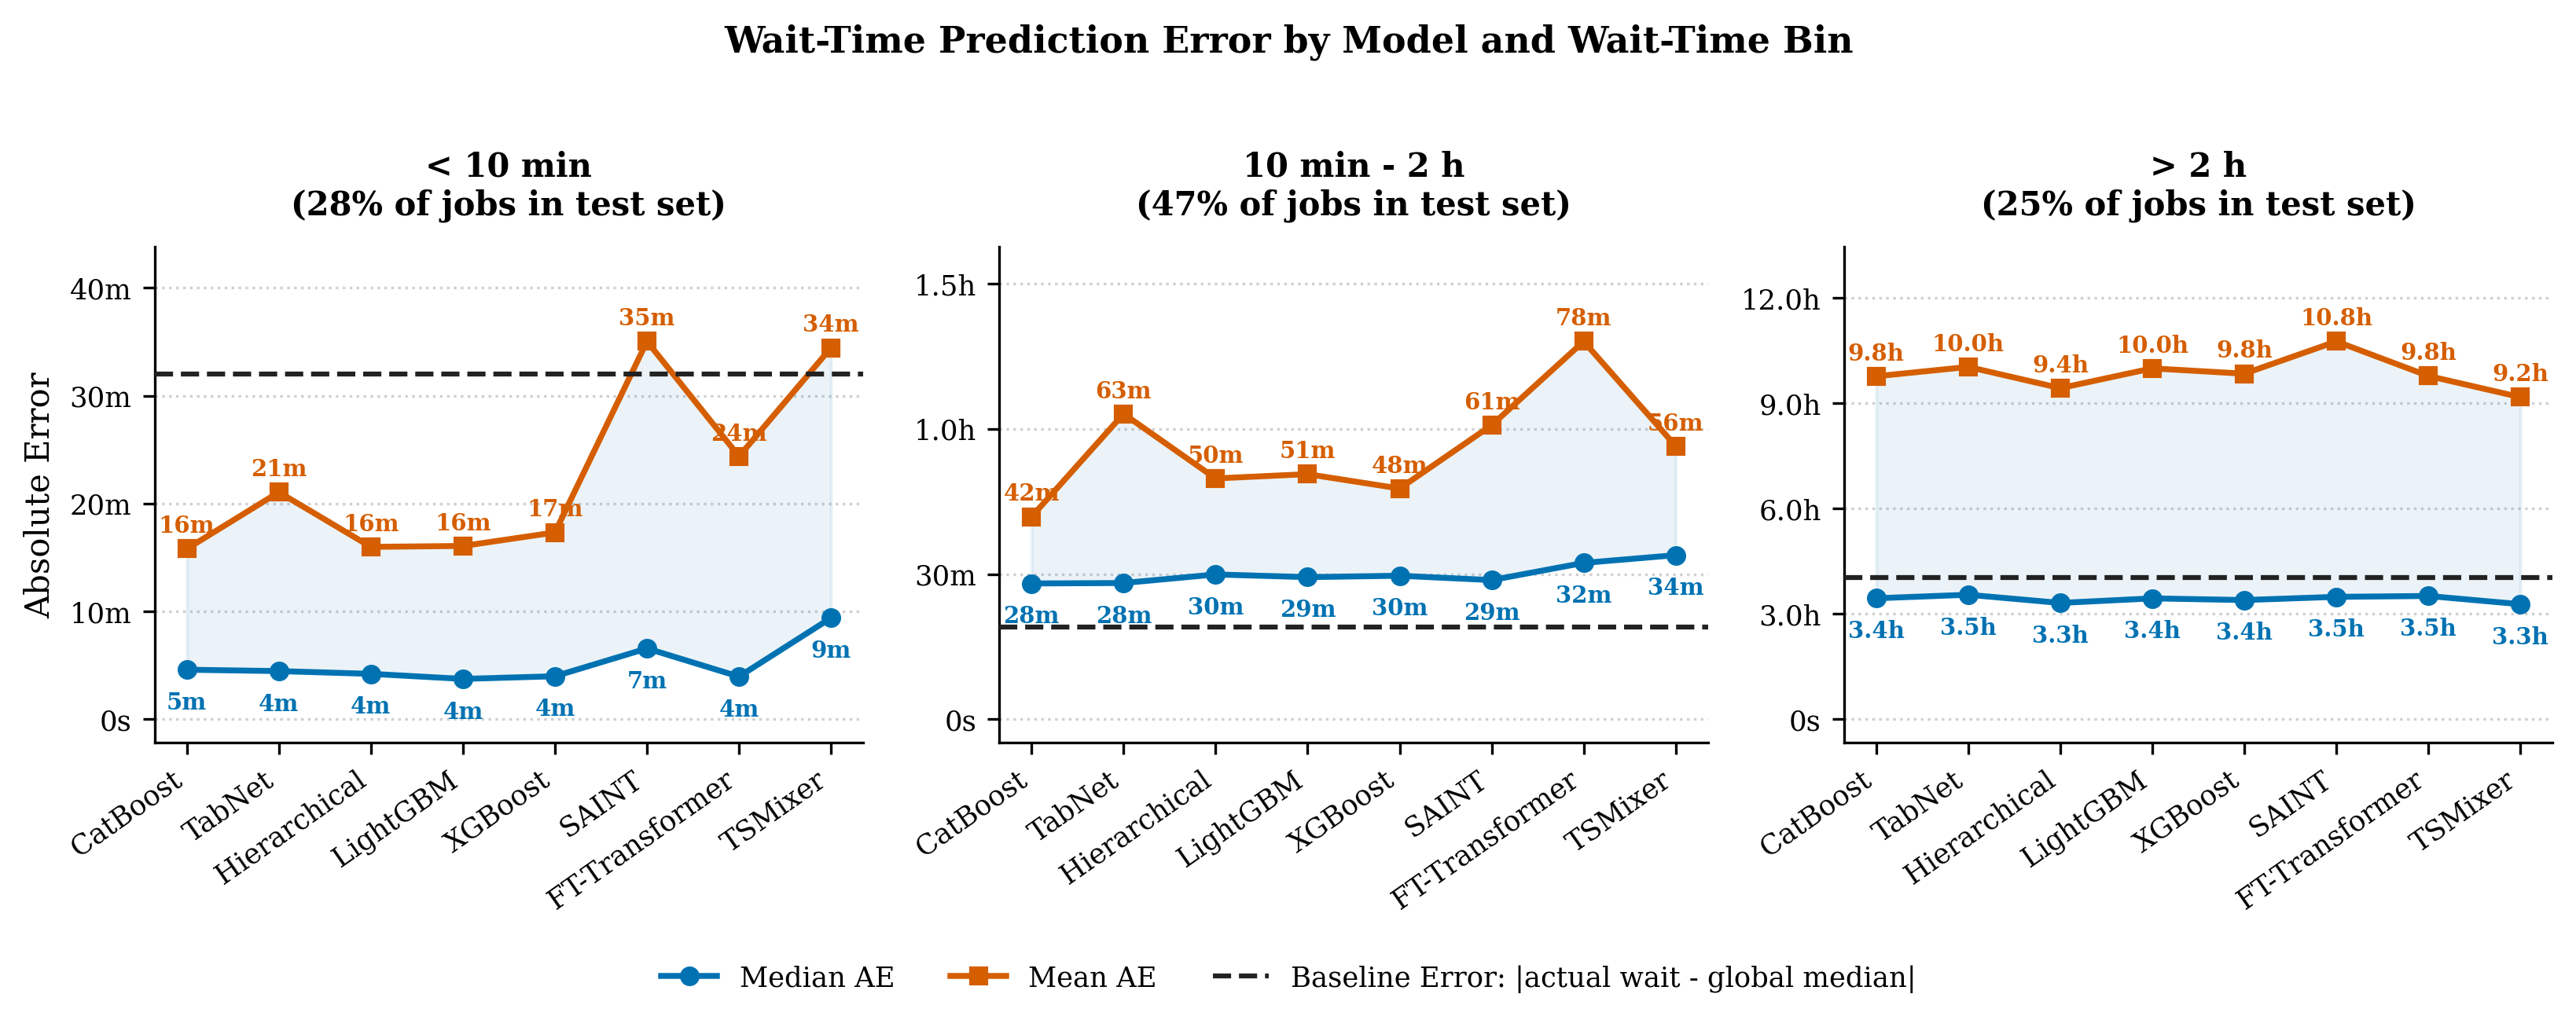

In [7]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# 1. Clean and inspect test wait times
y_test_raw = np.asarray(wait_sv[te_mask], dtype=np.float64).ravel()
y_test_raw = y_test_raw[~np.isnan(y_test_raw)]  # Drop NaNs

# Auto-detect log-transformed wait times (e.g., log1p seconds max out ~10-15)
if y_test_raw.max() < 25.0:
  y_test_raw = np.expm1(y_test_raw)

# Auto-detect millisecond wait times (e.g., values in 1e6+)
if np.median(y_test_raw) > 100000:
  y_test_raw = y_test_raw / 1000.0

global_median_wait = float(np.median(y_test_raw))

print(f"Test samples: {len(y_test_raw):,}")
print(
    f"Wait range: {y_test_raw.min():.1f}s to {y_test_raw.max():.1f}s | Global"
    f" Median: {global_median_wait:.1f}s ({global_median_wait/60:.1f}m)"
)

# 2. Figure styling
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8.5,
        "figure.titlesize": 11,
        "axes.grid": True,
        "grid.linestyle": ":",
        "grid.alpha": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

COLORS = {
    "primary": "#0072B2",  # Median AE
    "secondary": "#D55E00",  # Mean AE
    "baseline": "#222222",  # Baseline contrast line
}

BINS = [
    ("< 10 min", "median_ae_10m", "mae_10m", (0, 600)),
    ("10 min - 2 h", "median_ae_2h", "mae_2h", (600, 7200)),
    ("> 2 h", "median_ae_long", "mae_long", (7200, None)),
]


def _dur(s, min_unit=5400):
  if s <= 0:
    return "0s"
  if s < 60:
    return f"{s:.0f}s"
  if s < min_unit:
    return f"{s / 60:.0f}m"
  if s < 86400:
    return f"{s / 3600:.1f}h"
  return f"{s / 86400:.1f}d"


def _nice_step(vmax):
  for step in (
      30,
      60,
      120,
      300,
      600,
      900,
      1800,
      3600,
      7200,
      10800,
      21600,
      43200,
  ):
    if vmax / step <= 5:
      return step
  return 86400


models = df_wait.index.tolist()
x = np.arange(len(models))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), dpi=300)

for ax, (label, med_k, mean_k, (lo, hi)) in zip(axes, BINS):
  med = df_wait[med_k].values
  mean = df_wait[mean_k].values

  # Filter test jobs falling into this specific bin
  msk = (
      (y_test_raw >= lo) & (y_test_raw < hi)
      if hi is not None
      else (y_test_raw >= lo)
  )

  # Baseline error: median absolute error when predicting global median
  if msk.any():
    base_ae = float(np.median(np.abs(y_test_raw[msk] - global_median_wait)))
    bin_pct = msk.mean()
  else:
    base_ae = 0.0
    bin_pct = 0.0

  # Model lines
  ax.plot(
      x,
      med,
      marker="o",
      linewidth=1.8,
      markersize=5,
      color=COLORS["primary"],
      label="Median AE",
      zorder=4,
  )
  ax.plot(
      x,
      mean,
      marker="s",
      linewidth=1.8,
      markersize=5,
      color=COLORS["secondary"],
      label="Mean AE",
      zorder=4,
  )
  ax.fill_between(
      x, med, mean, color=COLORS["primary"], alpha=0.08, zorder=2
  )

  # Baseline horizontal line
  if base_ae > 0:
    ax.axhline(
        base_ae,
        ls="--",
        lw=1.5,
        color=COLORS["baseline"],
        zorder=5,
        label="Baseline Error: |actual wait - global median|",
    )

  # Point labels
  for i, (m_val, mean_val) in enumerate(zip(med, mean)):
    ax.annotate(
        _dur(m_val),
        (x[i], m_val),
        textcoords="offset points",
        xytext=(0, -12),
        ha="center",
        fontsize=7,
        color=COLORS["primary"],
        fontweight="bold",
    )
    ax.annotate(
        _dur(mean_val),
        (x[i], mean_val),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=7,
        color=COLORS["secondary"],
        fontweight="bold",
    )

  # Axis scaling
  top = max(max(mean.max(), med.max()), base_ae) * 1.25
  ax.set_ylim(-0.05 * top, top)

  step = _nice_step(top)
  ax.yaxis.set_major_locator(mticker.MultipleLocator(step))
  ax.yaxis.set_major_formatter(
      mticker.FuncFormatter(lambda v, _: _dur(v, 3600))
  )

  ax.set_title(f"{label}\n({bin_pct:.0%} of jobs in test set)", pad=10, fontweight="bold")
  ax.set_xticks(x)
  ax.set_xticklabels(models, rotation=35, ha="right")
  ax.grid(axis="x", visible=False)
  ax.set_axisbelow(True)

axes[0].set_ylabel("Absolute Error")

# Collect legend handles uniquely across all subplots
handles_dict = {}
for ax in axes:
  h_list, l_list = ax.get_legend_handles_labels()
  for h, l in zip(h_list, l_list):
    if l not in handles_dict:
      handles_dict[l] = h

fig.legend(
    handles_dict.values(),
    handles_dict.keys(),
    loc="lower center",
    ncol=len(handles_dict),
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
)

fig.suptitle(
    f"Wait-Time Prediction Error by Model and Wait-Time Bin",
    y=1.03,
    fontsize=11,
    fontweight="bold",
)

os.makedirs("output", exist_ok=True)
plt.tight_layout()
plt.savefig("output/wait_error_by_bin.pdf", bbox_inches="tight")
plt.show()